# 05. Аналитика качества и оптимальных режимов

Цель этапа: выполнить аналитическую часть задания:

- найти порог акустического/вибрационного признака, после которого качество ухудшается;
- подобрать оптимальные режимы фрезерования для заданной чистоты поверхности.

В этом ноутбуке принят допуск `Ra <= 3.2`. Это практичная граница для демо-прототипа; при необходимости ее можно поменять в переменной `RA_TOLERANCE`.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR = PROJECT_ROOT / "reports" / "models"
ANALYTICS_DIR = PROJECT_ROOT / "reports" / "analytics"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ANALYTICS_DIR.mkdir(parents=True, exist_ok=True)

RA_TOLERANCE = 3.2
TARGET_RA_CLEAN = 2.0

print("Корень проекта:", PROJECT_ROOT)
print("Допуск качества Ra <=", RA_TOLERANCE)
print("Цель для чистой обработки Ra <=", TARGET_RA_CLEAN)

Корень проекта: C:\Users\ivan.kopytin\Desktop\уник\surface_roughness_project
Допуск качества Ra <= 3.2
Цель для чистой обработки Ra <= 2.0


## 1. Загружаем признаки и лучшую модель

Берем `features.csv` и лучшую модель, сохраненную на этапе обучения. Дальше для каждого запуска добавим прогноз `predicted_ra`.


In [2]:
from analytics import (
    add_model_predictions,
    add_quality_labels,
    condition_prediction_summary,
    load_model_artifact,
)

features = pd.read_csv(DATA_PROCESSED / "features.csv")
model_artifact = load_model_artifact(MODELS_DIR / "best_roughness_model.joblib")

predicted = add_model_predictions(features, model_artifact)
labeled = add_quality_labels(predicted, tolerance_ra=RA_TOLERANCE)

print("Модель:", model_artifact["model_name"])
print("Размер таблицы:", labeled.shape)
print("Доля запусков хуже допуска:", round(labeled["is_bad_quality"].mean(), 3))

display(labeled[["condition_id", "run_id", "roughness_ra", "predicted_ra", "quality_label"]].head())

Модель: Linear Regression
Размер таблицы: (319, 48)
Доля запусков хуже допуска: 0.439


,condition_id,run_id,roughness_ra,predicted_ra,quality_label
0,f5_s250_d0.25,1,1.57,2.366236,ok
1,f5_s250_d0.25,2,1.57,1.650747,ok
2,f5_s250_d0.25,3,1.57,1.611260,ok
3,f5_s250_d0.25,4,1.57,1.644931,ok
4,f5_s250_d0.25,5,1.57,1.968094,ok


## 2. Порог признака, после которого качество падает

В датасете нет отдельного датчика вибрации, но акустические RMS/спектральные признаки можно использовать как proxy-оценку уровня вибраций/шума. Ищем порог, который лучше отделяет режимы `Ra > 3.2` от годных.


In [3]:
from analytics import threshold_report

threshold_features = [
    "xml_rms_mean",
    "sig_rms",
    "sig_abs_mean",
    "spec_power_total",
    "spec_power_2000_8000",
    "spec_high_to_low_ratio",
]

thresholds = threshold_report(labeled, threshold_features, tolerance_ra=RA_TOLERANCE)
thresholds.to_csv(ANALYTICS_DIR / "quality_thresholds.csv", index=False, encoding="utf-8")

display(thresholds)

best_threshold = thresholds.iloc[0]
print("Лучший порог:")
print(best_threshold["feature"], best_threshold["direction"], round(best_threshold["threshold"], 6))
print("Доля брака после порога:", round(best_threshold["bad_rate_after_threshold"], 3))
print("Доля брака до порога:", round(best_threshold["bad_rate_before_threshold"], 3))

,feature,direction,threshold,bad_rate_after_threshold,bad_rate_before_threshold,bad_rate_lift,samples_after_threshold,samples_before_threshold,balanced_accuracy,precision_bad,recall_bad,tp,tn,fp,fn,corr_with_roughness_ra
0,spec_power_2000_8000,>=,0.001605,0.697368,0.203593,0.493776,152,167,0.750080,0.697368,0.757143,106.0,133.0,46.0,34.0,0.630617
1,spec_high_to_low_ratio,>=,0.144452,0.868132,0.267544,0.600588,91,228,0.748623,0.868132,0.564286,79.0,167.0,12.0,61.0,0.340062
2,xml_rms_mean,>=,0.299971,0.780822,0.337398,0.443424,73,246,0.658879,0.780822,0.407143,57.0,163.0,16.0,83.0,0.510693
3,sig_rms,>=,0.227356,0.750000,0.334728,0.415272,80,239,0.658420,0.750000,0.428571,60.0,159.0,20.0,80.0,0.519543
4,sig_abs_mean,>=,0.179731,0.750000,0.334728,0.415272,80,239,0.658420,0.750000,0.428571,60.0,159.0,20.0,80.0,0.516708
5,spec_power_total,>=,0.055890,0.750000,0.334728,0.415272,80,239,0.658420,0.750000,0.428571,60.0,159.0,20.0,80.0,0.535824


Лучший порог:
spec_power_2000_8000 >= 0.001605
Доля брака после порога: 0.697
Доля брака до порога: 0.204


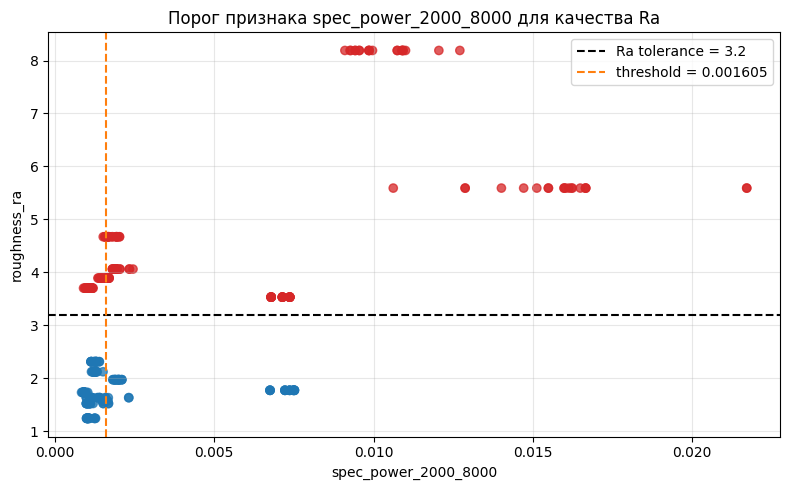

In [4]:
feature_name = best_threshold["feature"]
threshold_value = best_threshold["threshold"]

plt.figure(figsize=(8, 5))
colors = labeled["is_bad_quality"].map({False: "tab:blue", True: "tab:red"})
plt.scatter(labeled[feature_name], labeled["roughness_ra"], c=colors, alpha=0.75)
plt.axhline(RA_TOLERANCE, color="black", linestyle="--", label=f"Ra tolerance = {RA_TOLERANCE}")
plt.axvline(threshold_value, color="tab:orange", linestyle="--", label=f"threshold = {threshold_value:.6f}")
plt.title(f"Порог признака {feature_name} для качества Ra")
plt.xlabel(feature_name)
plt.ylabel("roughness_ra")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "quality_threshold_best_feature.png", dpi=150)
plt.show()

## 3. Анализ режимов обработки

Агрегируем прогнозы по режимам. Дополнительно считаем простой proxy производительности: `feed_mm * speed_rpm * depth_mm`. Он нужен, чтобы среди годных режимов выбирать более быстрые.


In [5]:
summary = condition_prediction_summary(labeled)
summary.to_csv(ANALYTICS_DIR / "condition_prediction_summary.csv", index=False, encoding="utf-8")

display(summary[[
    "condition_id",
    "feed_mm",
    "speed_rpm",
    "depth_mm",
    "roughness_ra",
    "predicted_ra_mean",
    "xml_rms_mean",
    "productivity_proxy",
]])

,condition_id,feed_mm,speed_rpm,depth_mm,roughness_ra,predicted_ra_mean,xml_rms_mean,productivity_proxy
0,f5_s500_d0.25,5.0,500,0.25,1.24,0.959812,0.113058,625.0
1,f5_s500_d0.5,5.0,500,0.50,1.52,1.543000,0.117534,1250.0
2,f10_s500_d0.25,10.0,500,0.25,1.73,1.717029,0.100616,1250.0
3,f5_s250_d0.25,5.0,250,0.25,1.57,1.735767,0.110698,312.5
4,f5_s500_d0.75,5.0,500,0.75,1.63,1.854633,0.120709,1875.0
5,f5_s500_d1,5.0,500,1.00,1.77,1.939563,0.326780,2500.0
6,f5_s250_d0.5,5.0,250,0.50,1.97,2.212401,0.123627,625.0
7,f10_s500_d0.5,10.0,500,0.50,2.12,2.365041,0.119780,2500.0
8,f10_s500_d0.75,10.0,500,0.75,2.31,2.456772,0.122702,3750.0
9,f10_s250_d0.25,10.0,250,0.25,3.70,3.445018,0.088985,625.0


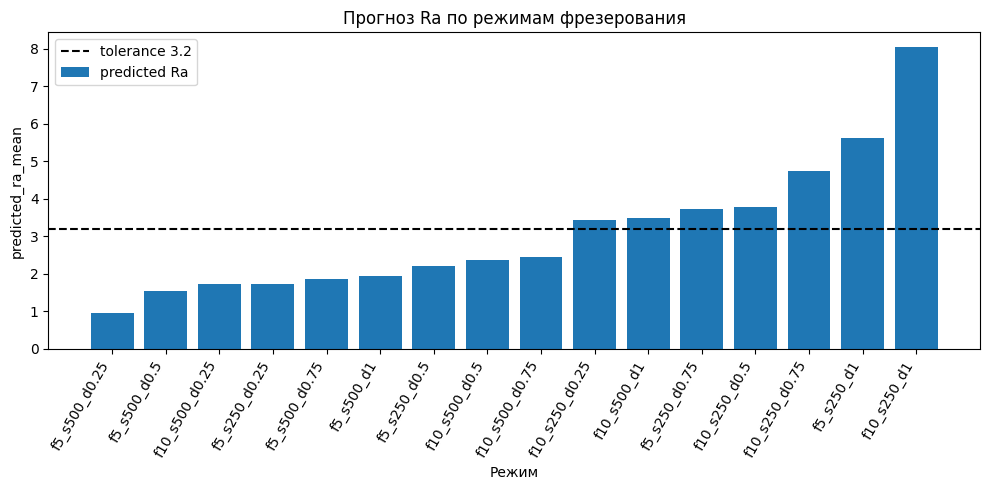

In [6]:
plt.figure(figsize=(10, 5))
plot_data = summary.sort_values("predicted_ra_mean")
plt.bar(plot_data["condition_id"], plot_data["predicted_ra_mean"], label="predicted Ra")
plt.axhline(RA_TOLERANCE, color="black", linestyle="--", label=f"tolerance {RA_TOLERANCE}")
plt.title("Прогноз Ra по режимам фрезерования")
plt.xlabel("Режим")
plt.ylabel("predicted_ra_mean")
plt.xticks(rotation=60, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "predicted_ra_by_condition.png", dpi=150)
plt.show()

## 4. Оптимальные режимы для заданной чистоты

Ранжируем режимы так: сначала фильтруем по прогнозу `Ra <= target`, затем выбираем более производительный режим. Такая логика полезна для прототипа приложения.


In [7]:
from analytics import recommend_modes

recommendations_tolerance = recommend_modes(summary, target_ra=RA_TOLERANCE, use_prediction=True)
recommendations_clean = recommend_modes(summary, target_ra=TARGET_RA_CLEAN, use_prediction=True)

recommendations_tolerance.to_csv(ANALYTICS_DIR / "recommendations_ra_3_2.csv", index=False, encoding="utf-8")
recommendations_clean.to_csv(ANALYTICS_DIR / "recommendations_ra_2_0.csv", index=False, encoding="utf-8")

print("Режимы для допуска Ra <=", RA_TOLERANCE)
display(recommendations_tolerance[[
    "condition_id",
    "feed_mm",
    "speed_rpm",
    "depth_mm",
    "roughness_ra",
    "predicted_ra_mean",
    "productivity_proxy",
    "margin_to_target",
]])

print("Режимы для более чистой обработки Ra <=", TARGET_RA_CLEAN)
display(recommendations_clean[[
    "condition_id",
    "feed_mm",
    "speed_rpm",
    "depth_mm",
    "roughness_ra",
    "predicted_ra_mean",
    "productivity_proxy",
    "margin_to_target",
]])

Режимы для допуска Ra <= 3.2


,condition_id,feed_mm,speed_rpm,depth_mm,roughness_ra,predicted_ra_mean,productivity_proxy,margin_to_target
0,f10_s500_d0.75,10.0,500,0.75,2.31,2.456772,3750.0,0.743228
1,f5_s500_d1,5.0,500,1.00,1.77,1.939563,2500.0,1.260437
2,f10_s500_d0.5,10.0,500,0.50,2.12,2.365041,2500.0,0.834959
3,f5_s500_d0.75,5.0,500,0.75,1.63,1.854633,1875.0,1.345367
4,f5_s500_d0.5,5.0,500,0.50,1.52,1.543000,1250.0,1.657000
5,f10_s500_d0.25,10.0,500,0.25,1.73,1.717029,1250.0,1.482971
6,f5_s500_d0.25,5.0,500,0.25,1.24,0.959812,625.0,2.240188
7,f5_s250_d0.5,5.0,250,0.50,1.97,2.212401,625.0,0.987599
8,f5_s250_d0.25,5.0,250,0.25,1.57,1.735767,312.5,1.464233


Режимы для более чистой обработки Ra <= 2.0


,condition_id,feed_mm,speed_rpm,depth_mm,roughness_ra,predicted_ra_mean,productivity_proxy,margin_to_target
0,f5_s500_d1,5.0,500,1.00,1.77,1.939563,2500.0,0.060437
1,f5_s500_d0.75,5.0,500,0.75,1.63,1.854633,1875.0,0.145367
2,f5_s500_d0.5,5.0,500,0.50,1.52,1.543000,1250.0,0.457000
3,f10_s500_d0.25,10.0,500,0.25,1.73,1.717029,1250.0,0.282971
4,f5_s500_d0.25,5.0,500,0.25,1.24,0.959812,625.0,1.040188
5,f5_s250_d0.25,5.0,250,0.25,1.57,1.735767,312.5,0.264233


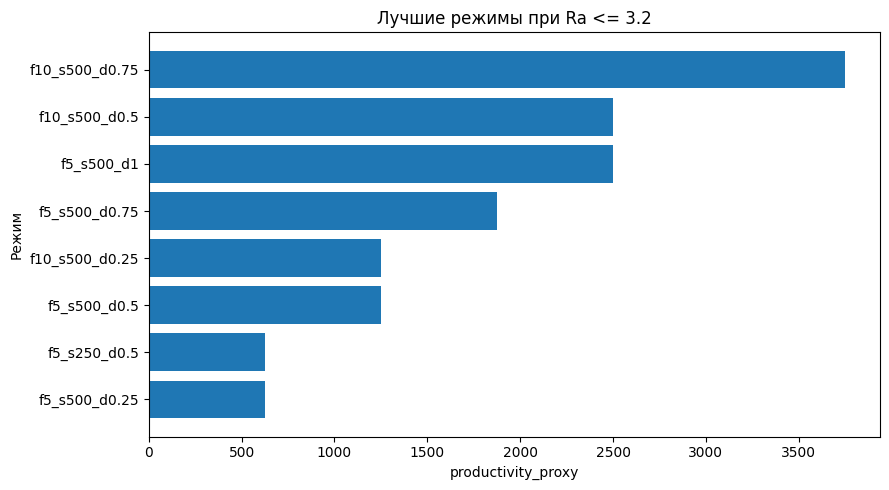

In [8]:
plt.figure(figsize=(9, 5))
plot_rec = recommendations_tolerance.head(8).sort_values("productivity_proxy")
plt.barh(plot_rec["condition_id"], plot_rec["productivity_proxy"])
plt.title(f"Лучшие режимы при Ra <= {RA_TOLERANCE}")
plt.xlabel("productivity_proxy")
plt.ylabel("Режим")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "recommended_modes_ra_3_2.png", dpi=150)
plt.show()

## 5. Итоговые выводы

1. Порог по лучшему акустическому признаку сохранен в `reports/analytics/quality_thresholds.csv`.
2. Оптимальные режимы для `Ra <= 3.2` и `Ra <= 2.0` сохранены в `reports/analytics`.
3. Самые опасные режимы по шероховатости - низкая скорость 250 rpm при большей глубине резания.
4. Для прототипа решение можно формулировать так: при превышении порога акустической энергии в диапазоне 2000-8000 Hz риск выхода за допуск существенно растет.
